In [1]:
import gymnasium as gym
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from assignment2_utils import describe_env, main
from taxi_agent import Agent

## Plots

Observation space:  Discrete(500)
Observation space size:  500
Reward Range:  (-inf, inf)
Number of actions:  6
Action description:  {0: 'Move south (down)', 1: 'Move north (up)', 2: 'Move east (right)', 3: 'Move west (left)', 4: 'Pickup passenger', 5: 'Drop off passenger'}


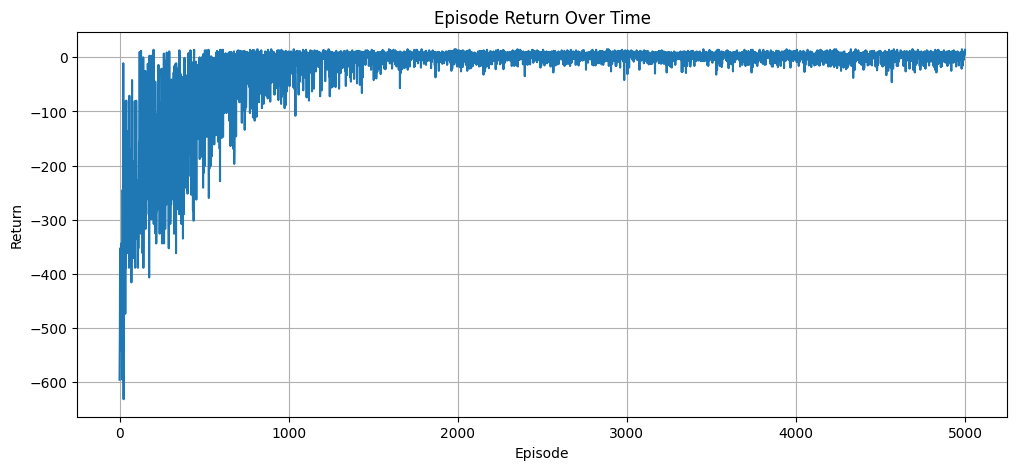

In [2]:
env = gym.make("Taxi-v3")
num_states, num_actions = describe_env(env)

agent = Agent(num_states, num_actions, alpha=0.1, epsilon=0.1, gamma=0.9)
returns, steps = agent.train(env, num_episodes=5000)

plt.figure(figsize=(12,5))
plt.plot(returns)
plt.title("Episode Return Over Time")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.grid(True)
plt.show()

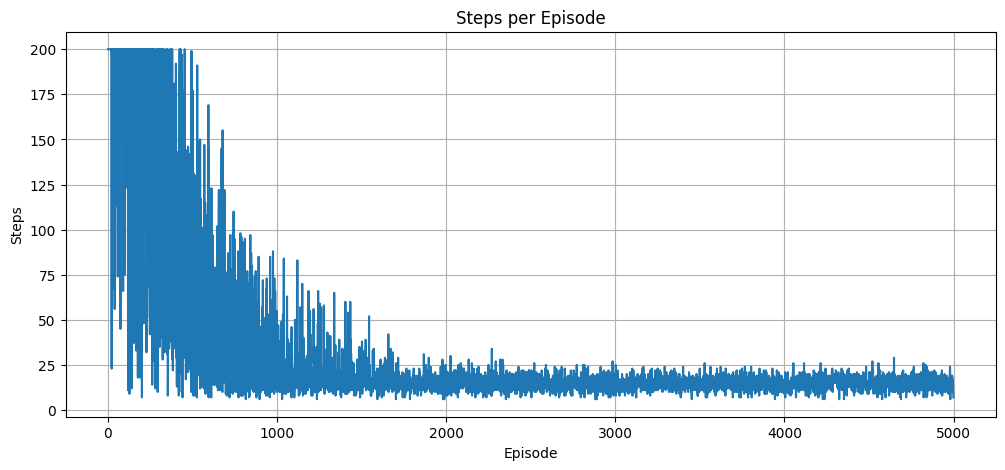

In [3]:
plt.figure(figsize=(12,5))
plt.plot(steps)
plt.title("Steps per Episode")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.grid(True)
plt.show()

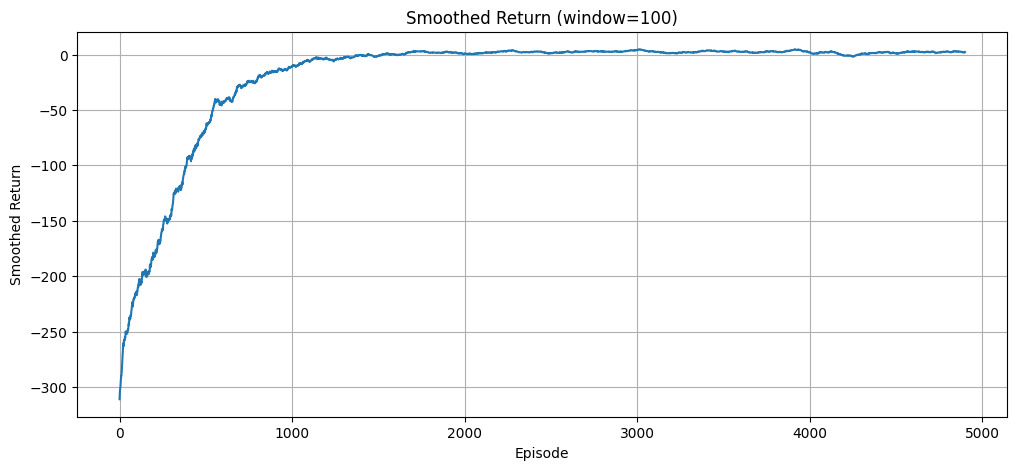

In [4]:
window = 100
smoothed = np.convolve(returns, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12,5))
plt.plot(smoothed)
plt.title(f"Smoothed Return (window={window})")
plt.xlabel("Episode")
plt.ylabel("Smoothed Return")
plt.grid(True)
plt.show()

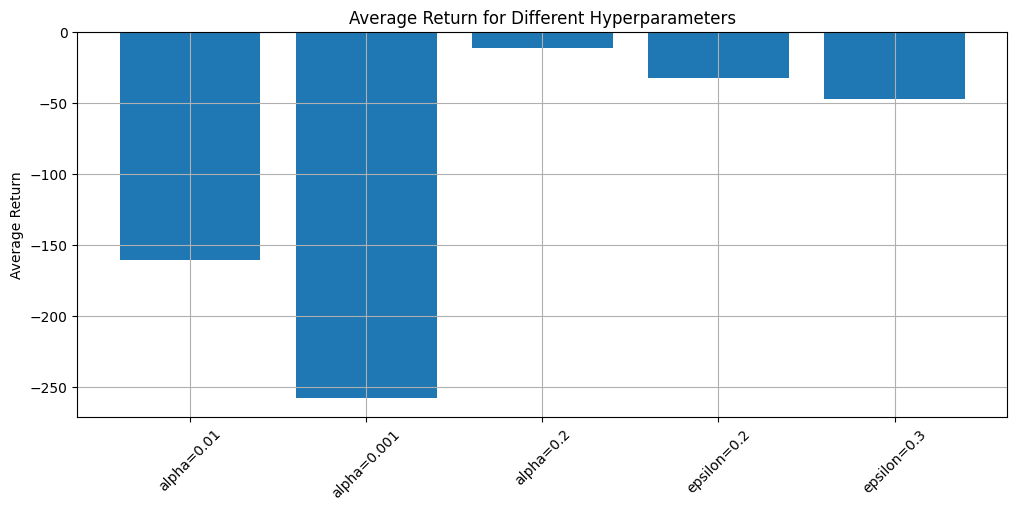

In [5]:
results = {}

alphas = [0.01, 0.001, 0.2]

for a in alphas:
    agent = Agent(num_states, num_actions, alpha=a, epsilon=0.1, gamma=0.9)
    returns, steps = agent.train(env, num_episodes=5000)

    # Store results in the dictionary
    results[f"alpha={a}"] = {
        "returns": returns,
        "steps": steps
    }

epsilons = [0.2, 0.3]

for e in epsilons:
    agent = Agent(num_states, num_actions, alpha=0.1, epsilon=e, gamma=0.9)
    returns, steps = agent.train(env, num_episodes=5000)

    results[f"epsilon={e}"] = {
        "returns": returns,
        "steps": steps
    }

labels = []
avg_returns = []

# Bar chart comparing average returns
for key, metrics in results.items():
    labels.append(key)
    avg_returns.append(np.mean(metrics["returns"]))

plt.figure(figsize=(12,5))
plt.bar(labels, avg_returns)
plt.title("Average Return for Different Hyperparameters")
plt.ylabel("Average Return")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [6]:
print(results)

{'alpha=0.01': {'returns': [-542, -533, -497, -560, -623, -551, -398, -569, -362, -425, -425, -245, -308, -254, -344, -578, -596, -356, -551, -569, -497, -173, -290, -272, -416, -371, -506, -281, -236, -272, -461, -226, -272, -144, -344, -218, -398, -281, -398, -362, -290, -218, -308, -254, -263, -227, -297, -263, -245, -254, -362, -299, -281, -254, -227, -236, -166, -272, -272, -308, -263, -290, -344, -272, -353, -254, -299, -214, -254, -335, -362, -281, -299, -299, -272, -371, -299, -299, -380, -290, -281, -263, -263, -362, -317, -263, -73, -299, -281, -176, -108, -260, -254, -227, -281, -362, -416, -245, -272, -299, -380, -398, -335, -281, -9, -272, -183, -218, -272, -272, -299, -290, -335, -125, -263, -362, -89, -272, -263, -299, -308, -254, -425, -317, -205, -218, -299, 13, -272, -353, -263, -209, -218, -380, -353, -263, -263, -317, -344, -272, -308, -272, -218, -389, -245, -299, -254, -344, -281, -272, -236, -236, -290, -290, -51, -434, -299, -263, -335, -263, -263, -263, -308, -

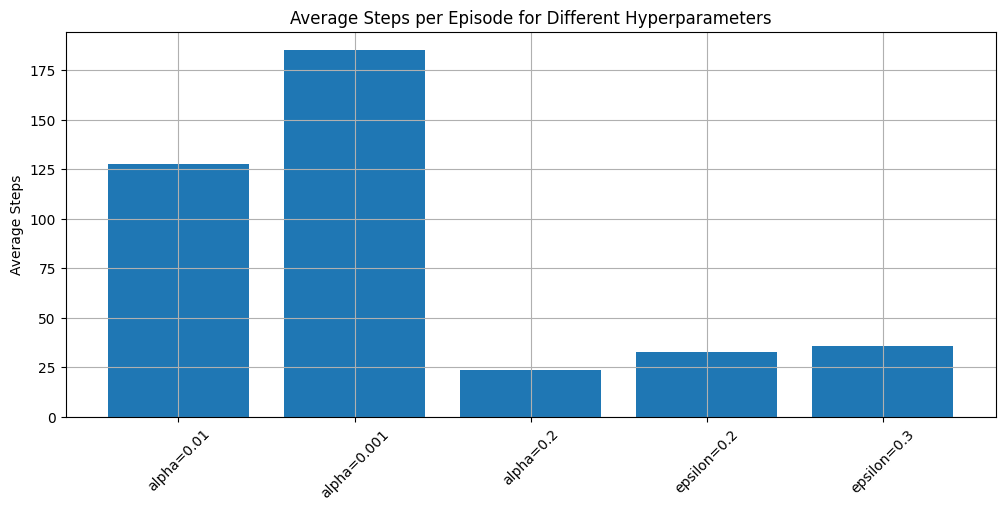

In [7]:
labels = []
avg_steps = []

for key, metrics in results.items():
    labels.append(key)
    avg_steps.append(np.mean(metrics["steps"]))

# Bar chart comparing average steps
plt.figure(figsize=(12,5))
plt.bar(labels, avg_steps)
plt.title("Average Steps per Episode for Different Hyperparameters")
plt.ylabel("Average Steps")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [8]:
for key, metrics in results.items():
    print(key, "avg return:", np.mean(metrics["returns"]))

alpha=0.01 avg return: -160.8826
alpha=0.001 avg return: -258.2454
alpha=0.2 avg return: -11.382
epsilon=0.2 avg return: -32.7412
epsilon=0.3 avg return: -47.301


In [9]:
for key, metrics in results.items():
    print(key, "avg steps:", np.mean(metrics["steps"]))

alpha=0.01 avg steps: 127.4266
alpha=0.001 avg steps: 185.016
alpha=0.2 avg steps: 23.4582
epsilon=0.2 avg steps: 32.8696
epsilon=0.3 avg steps: 35.8458


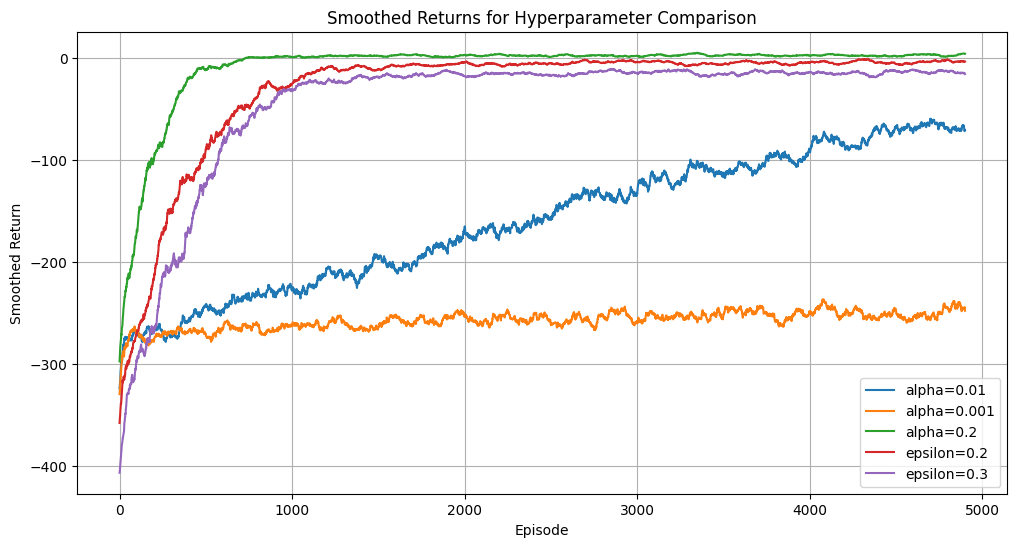

In [10]:
window = 100

plt.figure(figsize=(12,6))
for key, metrics in results.items():
    smoothed = np.convolve(metrics["returns"], np.ones(window) / window, mode='valid')
    plt.plot(smoothed, label=key)

plt.title("Smoothed Returns for Hyperparameter Comparison")
plt.xlabel("Episode")
plt.ylabel("Smoothed Return")
plt.legend()
plt.grid(True)
plt.show()

# Q-table heatmap

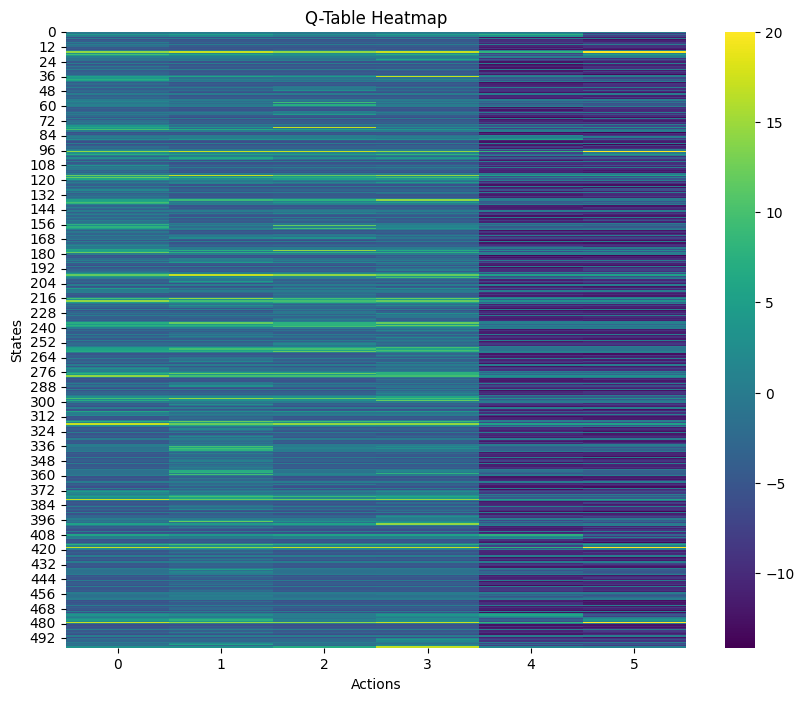

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(agent.Q, cmap="viridis")
plt.title("Q-Table Heatmap")
plt.xlabel("Actions")
plt.ylabel("States")
plt.show()

# Policy visualization

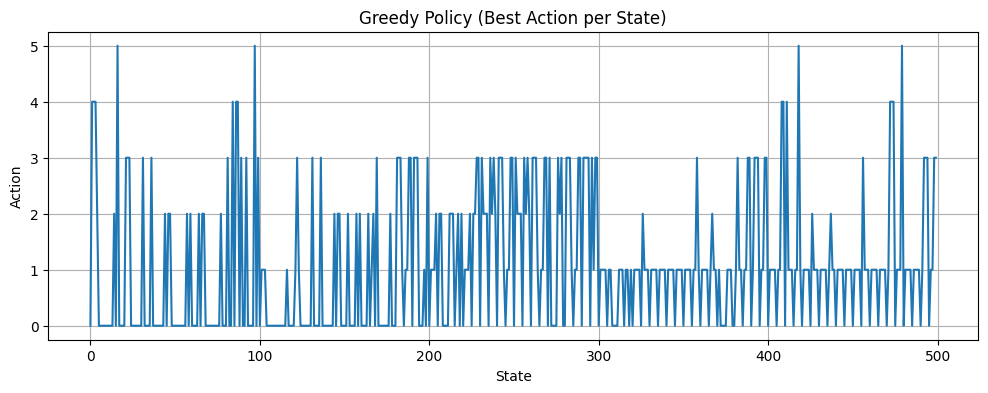

In [12]:
policy = np.argmax(agent.Q, axis=1)

plt.figure(figsize=(12,4))
plt.plot(policy)
plt.title("Greedy Policy (Best Action per State)")
plt.xlabel("State")
plt.ylabel("Action")
plt.grid(True)
plt.show()

# Run Taxi

In [13]:
main()

Observation space:  Discrete(500)
Observation space size:  500
Reward Range:  (-inf, inf)
Number of actions:  6
Action description:  {0: 'Move south (down)', 1: 'Move north (up)', 2: 'Move east (right)', 3: 'Move west (left)', 4: 'Pickup passenger', 5: 'Drop off passenger'}

=== Training with base hyperparameters ===
Total episodes: 5000
Average return: -22.0718
Average steps: 30.761

=== Testing different learning rates ===
alpha=0.01: avg return=-160.6374, avg steps=127.2852
alpha=0.001: avg return=-257.8706, avg steps=184.883
alpha=0.2: avg return=-11.3996, avg steps=23.3426

=== Testing different exploration factors ===
epsilon=0.2: avg return=-32.6918, avg steps=32.8394
epsilon=0.3: avg return=-47.0364, avg steps=35.8596

=== Final training with chosen best parameters ===
Total episodes: 5000
Average return: -20.7778
Average steps: 25.5934
Passenger is at: Blue, wants to go to Red. Taxi currently at (5.0, 1.0)
Action: Move south (down)
Action: Move east (right)
Action: Move east (